In [3]:
%load_ext autoreload
%autoreload 2
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings

import torch
import random
import math
import sys
sys.path.append("../..")  # Add parent directory to path
sys.path.append("../../../..")
from simple_synth import SimpleSynth
import scipy
import matplotlib
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 1/20, Current best: 0.3647, 


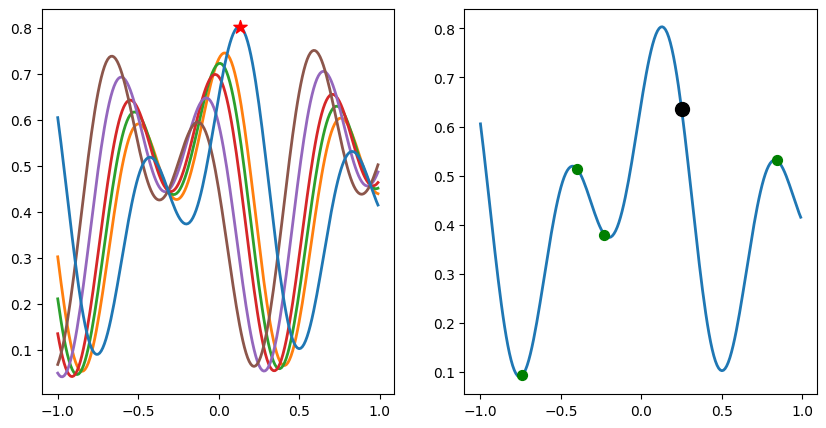

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 2/20, Current best: 0.2954, 


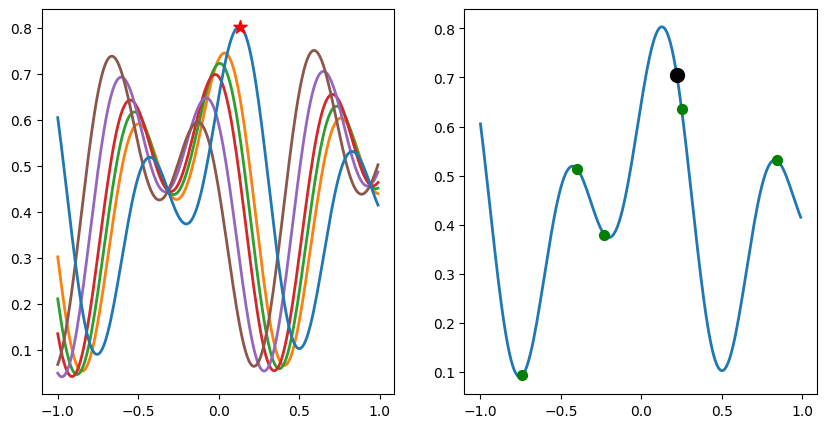

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 3/20, Current best: 0.2954, 


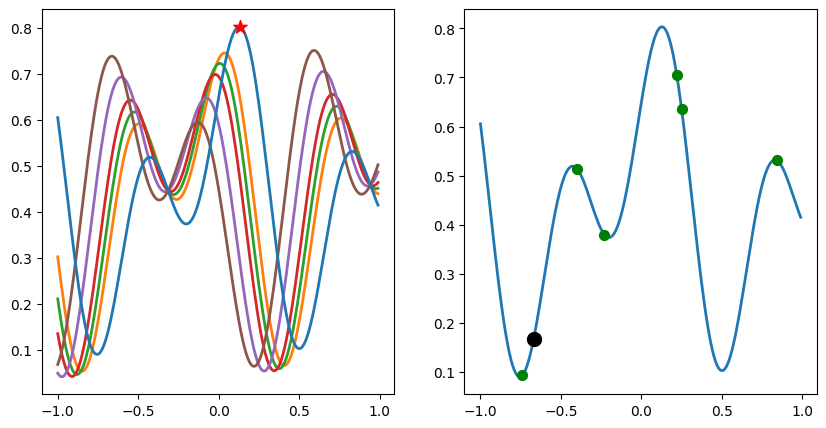

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 4/20, Current best: 0.2954, 


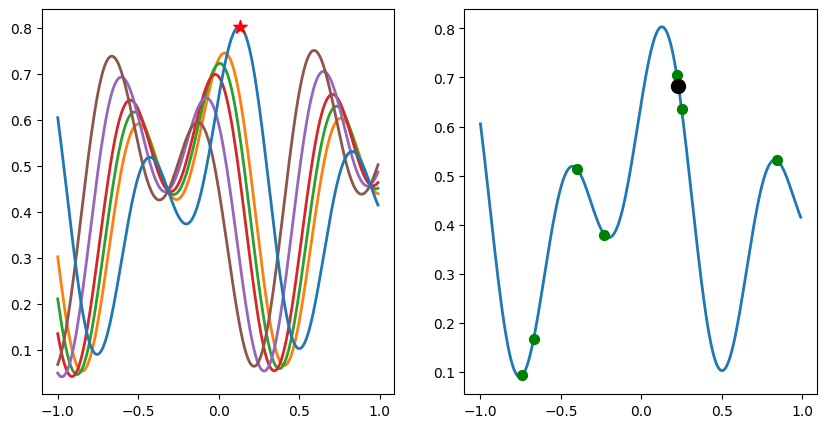

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 5/20, Current best: 0.2757, 


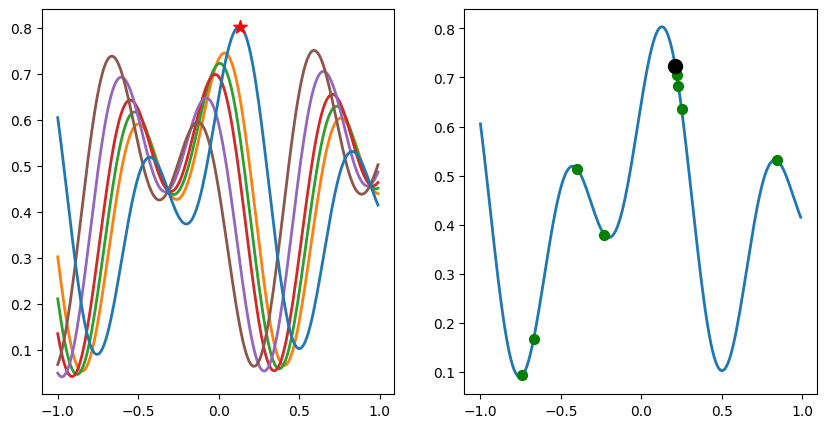

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 6/20, Current best: 0.2425, 


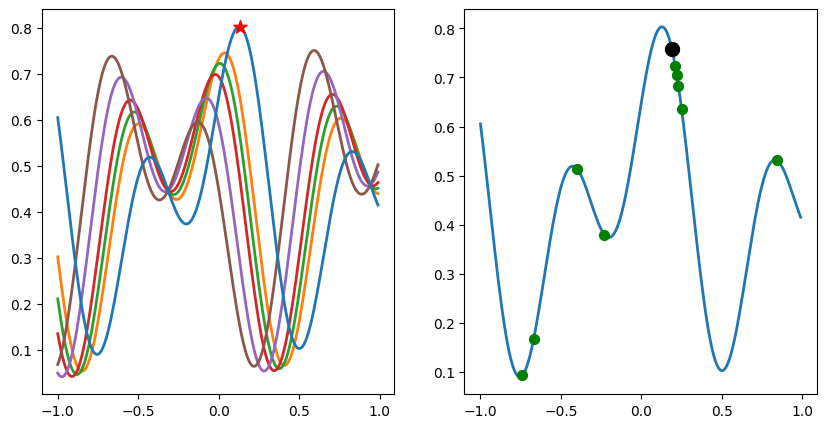

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 7/20, Current best: 0.2291, 


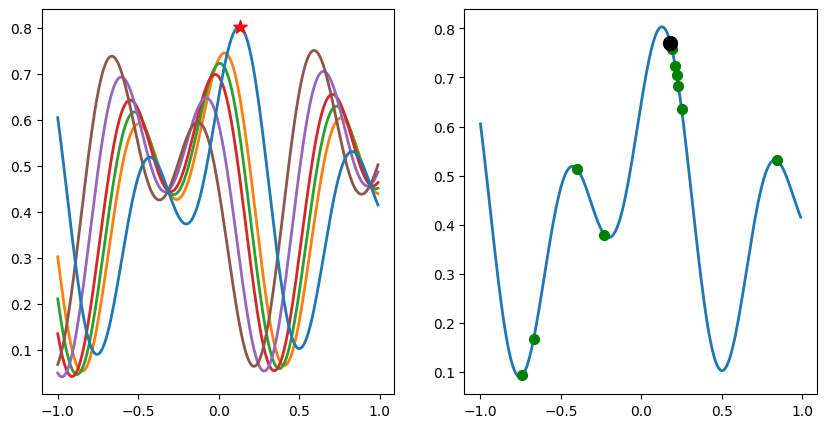

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 8/20, Current best: 0.2091, 


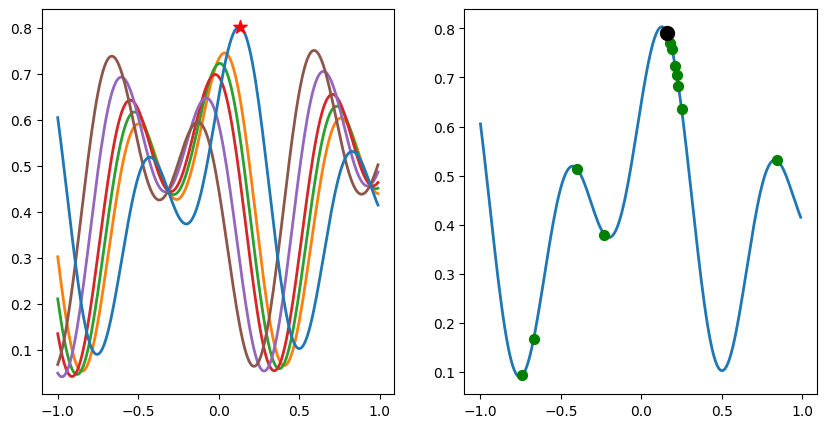

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 9/20, Current best: 0.1985, 


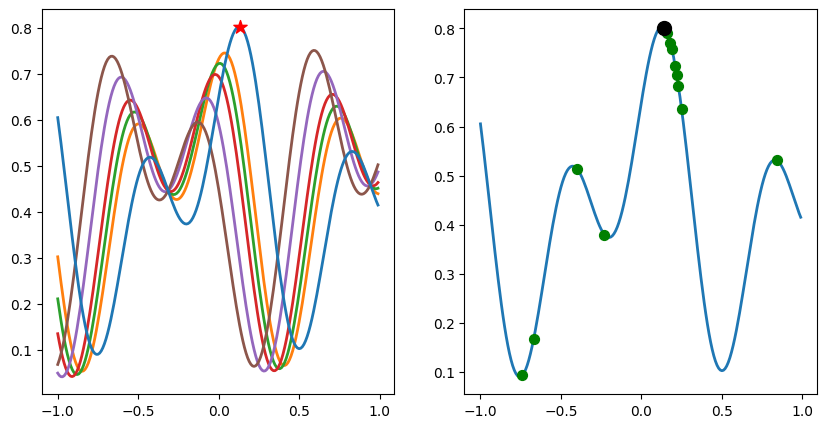

torch.Size([204, 2, 1]) torch.Size([204, 2])
Iteration 10/20, Current best: 0.1968, 


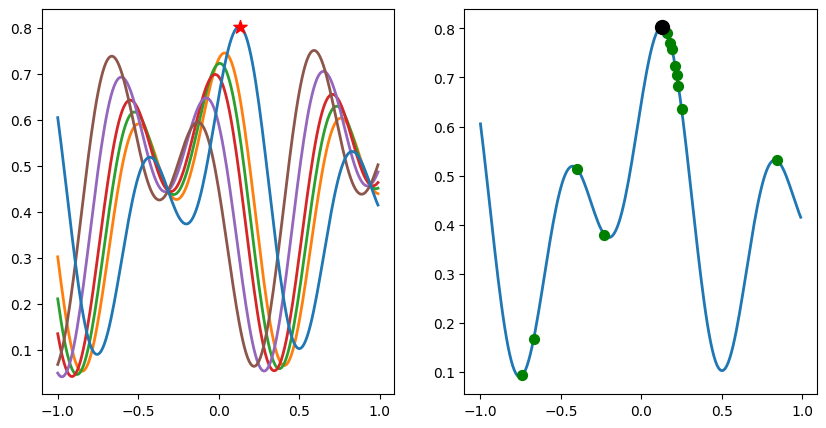

In [6]:
test_seed = "test4"
task_id = 0  # Task ID for the SimpleSynth benchmark
max_evaluations = 20

seed_num = int(''.join(filter(str.isdigit, test_seed)))
torch.manual_seed(seed_num)
np.random.seed(seed_num)
random.seed(seed_num)

benchmark = SimpleSynth(seed=test_seed, start_task=task_id, initializations=4)
#meta_data = benchmark.get_meta_data(task_ids=[3, 4, 5, 7, 11])
meta_data = benchmark.get_meta_data()
fontsize = 18
lw=2

import pfns4bo
# from mpfns4bo.mpfns4bo import MPFNs4BO
# optimizer = MPFNs4BO(torch.load( pfns4bo.hebo_plus_model), benchmark.search_space, meta_data, apply_power_transform=False,
#                     apply_power_transform_pi=True,
#                     only_obs_incumbents=True, tranformation_type=None, mixing_strategy="my",)
from mpfns4bo.ppfns4bo import PPFNs4BO
optimizer = PPFNs4BO(torch.load( pfns4bo.bnn_model), benchmark.search_space, meta_data, apply_power_transform_pi = True, model_avg='simple')

X = np.asarray(benchmark.benchmark_data["X"])
y = np.asarray(benchmark.benchmark_data["y"])
y = 1 - y

data_size = len(X)
# indices of pending evaluations
pending_evaluations = list(range(data_size))
current_evaluations = []

init_ids = benchmark.bo_initializations[test_seed]
for i in range(len(init_ids)):
    idx = init_ids[i]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)

min_regret_history = [np.min(y[current_evaluations])]
opt_time = []
for iteration in range(max_evaluations):
    fig, axs = plt.subplots(1,2, figsize=(10,5))

    
    not_init = np.setdiff1d(np.arange(data_size), init_ids)
    axs[0].plot(X[not_init], 1 - y[not_init], linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)

    task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]

    for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1) # return to maximization (performance)
        sort_idx = np.argsort(mX.flatten())
        axs[0].plot(mX[sort_idx], mY[sort_idx], linewidth=lw, label=task_names[i])


    axs[0].scatter([X[y.argmin()]], [1 - y.min()], marker="*", s=100, c= "red", zorder = 99)

    not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
    axs[1].plot(X[not_evaluated], 1 - y[not_evaluated], linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)
    axs[1].scatter(X[current_evaluations], 1 - y[current_evaluations], s= 50, c= "green", label="Observed Samples", zorder = 99)
    idx = optimizer.observe_and_suggest(
        X[current_evaluations], y[current_evaluations], X[pending_evaluations]
    )

    axs[1].scatter(X[pending_evaluations][idx], 1 - y[pending_evaluations][idx], s= 100, c= "black", label="Next Sample (with meta learning)", zorder = 99)
    idx = pending_evaluations[idx]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)
    min_regret_history.append(np.min(y[current_evaluations]))

    print(f"Iteration {iteration + 1}/{max_evaluations}, "
            f"Current best: {min_regret_history[-1]:.4f}, ")

    plt.show()


    if min(y) in min_regret_history:
        break

# negate to recover accuracy
min_regret_history += [min(y).item()] * (max_evaluations - i - 1)